<a href="https://colab.research.google.com/github/Lehuutien2908/DataMining/blob/main/research/training_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dự đoán nguy cơ mắc bệnh tim

Notebook này trình bày toàn bộ quy trình xử lý dữ liệu, xây dựng và so sánh các mô hình (MLP, Random Forest, XGBoost, SVM) nhằm dự đoán khả năng mắc bệnh tim dựa trên các chỉ số lâm sàng.


## Quy trình tổng quát
- Khảo sát dữ liệu, kiểm tra thiếu và ngoại lệ
- Làm sạch, chuẩn hóa và chọn đặc trưng
- Chia dữ liệu train/test (stratify theo nhãn)
- Huấn luyện MLP (Keras Sequential) và các mô hình so sánh: Random Forest, XGBoost, SVM
- Đánh giá Accuracy, Precision, Recall, F1, Specificity, AUC-ROC


## Association Rules với Apriori Algorithm

Phân tích luật kết hợp để tìm các mẫu và mối quan hệ giữa các đặc trưng trong dữ liệu bệnh tim.


In [2]:
# Trong cell đầu tiên, chạy:
!pip install torch torchvision


     ---------------------------------------- 0.0/111.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/111.0 MB ? eta -:--:--
     -------------------------------------- 0.0/111.0 MB 653.6 kB/s eta 0:02:50
     -------------------------------------- 0.0/111.0 MB 653.6 kB/s eta 0:02:50
     -------------------------------------- 0.1/111.0 MB 435.7 kB/s eta 0:04:15
     -------------------------------------- 0.1/111.0 MB 599.1 kB/s eta 0:03:06
     -------------------------------------- 0.1/111.0 MB 655.8 kB/s eta 0:02:50
     -------------------------------------- 0.2/111.0 MB 731.4 kB/s eta 0:02:32
     -------------------------------------- 0.3/111.0 MB 948.8 kB/s eta 0:01:57
     ---------------------------------------- 0.4/111.0 MB 1.2 MB/s eta 0:01:35
     ---------------------------------------- 0.6/111.0 MB 1.5 MB/s eta 0:01:16
     ---------------------------------------- 0.7/111.0 MB 1.4 MB/s eta 0:01:18
     ---------------------------------------- 0.8/111

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.0000

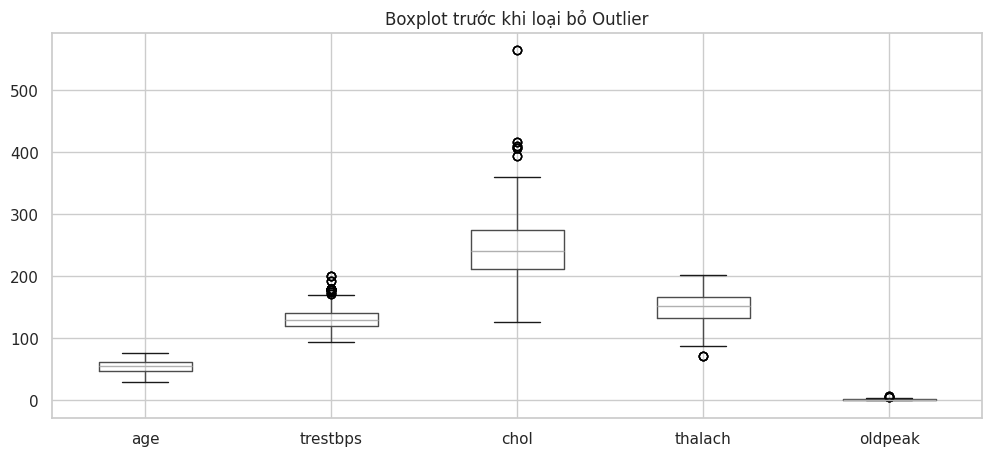

   - Cột 'trestbps': Loại bỏ 30 outliers.
   - Cột 'chol': Loại bỏ 16 outliers.
   - Cột 'thalach': Loại bỏ 4 outliers.
   - Cột 'oldpeak': Loại bỏ 11 outliers.
-> Đã loại bỏ tổng cộng 61 dòng nhiễu.
-> Kích thước dữ liệu sạch: (964, 14)


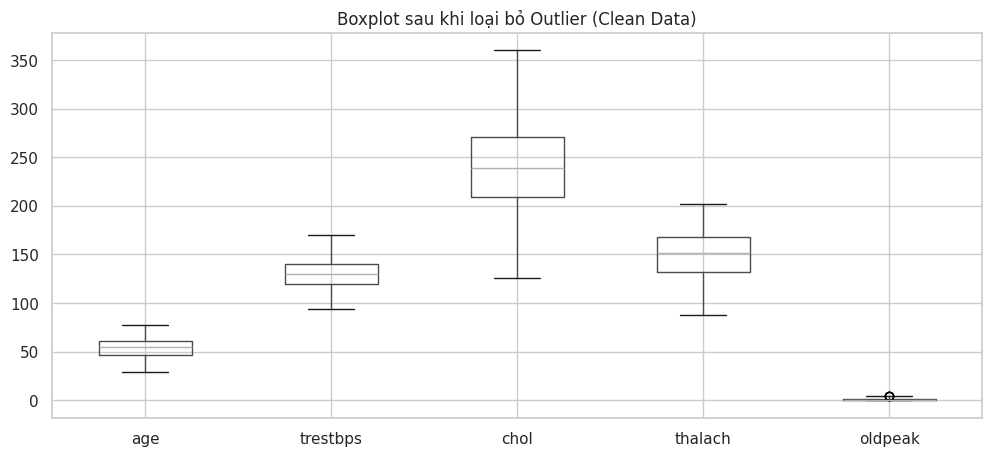

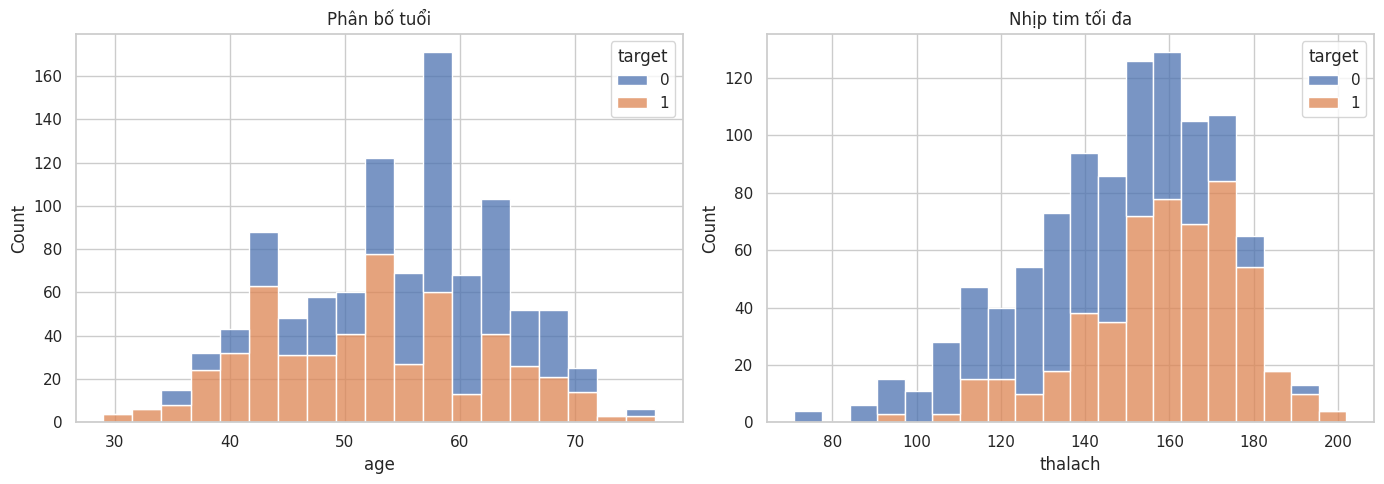

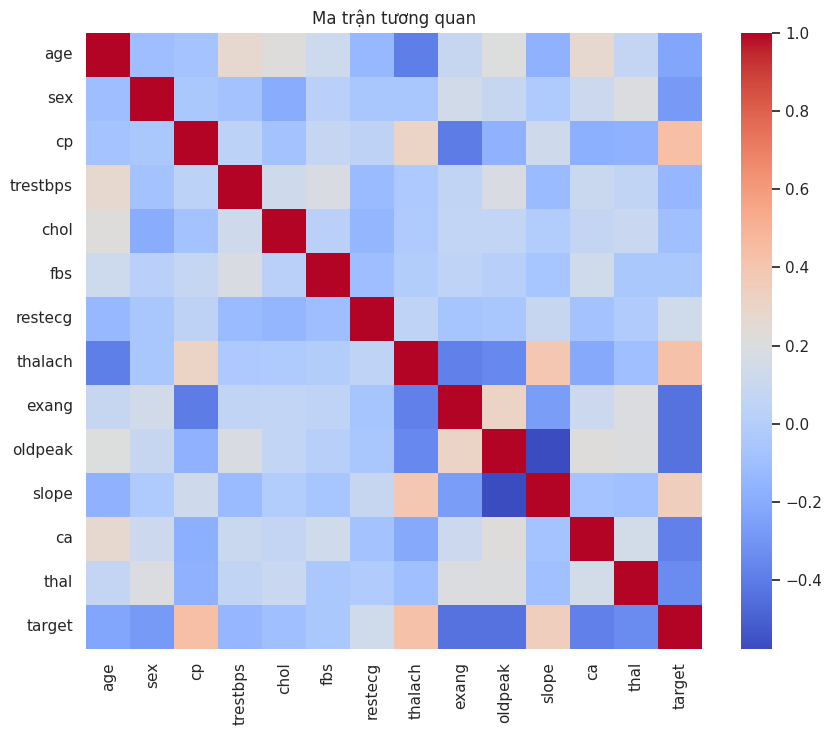

Train/Test: (674, 13) (290, 13)

=== FEATURE IMPORTANCE (RF) ===
oldpeak     0.125120
ca          0.119539
cp          0.118630
thalach     0.116835
thal        0.114101
age         0.092687
chol        0.071988
exang       0.063748
trestbps    0.063567
slope       0.043152
sex         0.038757
restecg     0.019958
fbs         0.011918
dtype: float64
Threshold = 0.01 | Features = 13 | AUC = 0.9974
Threshold = 0.02 | Features = 11 | AUC = 0.9937
Threshold = 0.03 | Features = 11 | AUC = 0.9937
Threshold = 0.04 | Features = 10 | AUC = 0.9950
Threshold = 0.05 | Features = 9 | AUC = 0.9921
Threshold = 0.06 | Features = 9 | AUC = 0.9921
Threshold = 0.07 | Features = 7 | AUC = 0.9898
Threshold = 0.08 | Features = 6 | AUC = 0.9916
Threshold = 0.09 | Features = 6 | AUC = 0.9916
Threshold = 0.10 | Features = 5 | AUC = 0.9851
THRESHOLD TỐI ƯU: 0.01
FEATURE ĐƯỢC CHỌN:
['oldpeak', 'ca', 'cp', 'thalach', 'thal', 'age', 'chol', 'exang', 'trestbps', 'slope', 'sex', 'restecg', 'fbs']
10/10 ━━━━━━━━━━━━

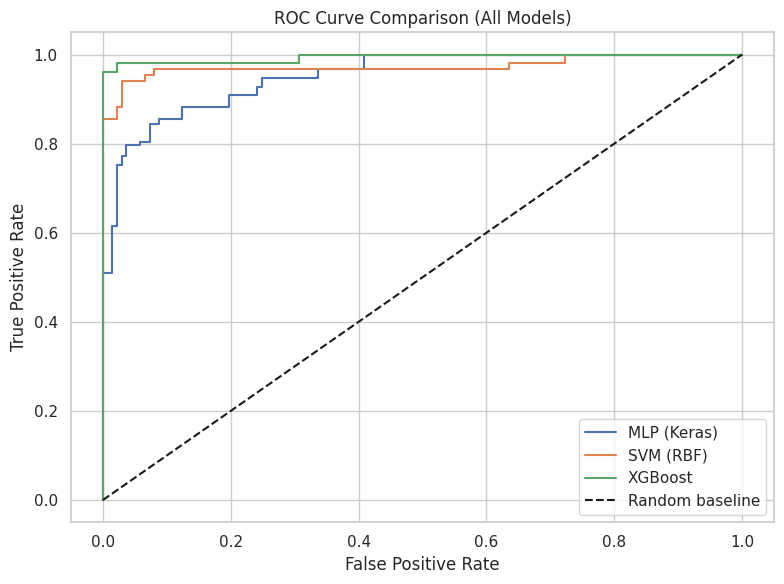

Đã lưu scaler.pkl và selector.pkl
Đã lưu xgb_model.json
Đã lưu mlp_model.h5
Đã lưu svm_model.pkl
Đã lưu rf_model.pkl


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,  recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

from sklearn.svm import SVC
import xgboost as xgb

import tensorflow as tf
from tensorflow import keras

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import joblib
import os

MODELS_DIR = Path("../backend/app/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# ============================
# Load dữ liệu
# ============================

DATA_PATH = Path("heart.csv")
raw_df = pd.read_csv(DATA_PATH)

print(raw_df.head())
print(raw_df.describe())
print(raw_df.isna().sum())

# ============================
# Xử lý Outlier (IQR Method)
# ============================

# Chỉ lọc trên các biến liên tục quan trọng
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

df = raw_df.copy()

# Boxplot trước khi xử lý để so sánh

plt.figure(figsize=(12, 5))
raw_df[continuous_cols].boxplot()
plt.title("Boxplot trước khi loại bỏ Outlier")
plt.show()

old_rows = df.shape[0]

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Đếm số lượng outlier sẽ bị loại
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if outliers_count > 0:
        print(f"   - Cột '{col}': Loại bỏ {outliers_count} outliers.")

    # Lọc dữ liệu
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"-> Đã loại bỏ tổng cộng {old_rows - df.shape[0]} dòng nhiễu.")
print(f"-> Kích thước dữ liệu sạch: {df.shape}")

# Boxplot sau khi xử lý
plt.figure(figsize=(12, 5))
df[continuous_cols].boxplot()
plt.title("Boxplot sau khi loại bỏ Outlier (Clean Data)")
plt.show()

# ============================
# EDA nhanh (Optional)
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=raw_df, x="age", hue="target", multiple="stack", ax=axes[0])
sns.histplot(data=raw_df, x="thalach", hue="target", multiple="stack", ax=axes[1])
axes[0].set_title("Phân bố tuổi")
axes[1].set_title("Nhịp tim tối đa")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(raw_df.corr(numeric_only=True), cmap="coolwarm", square=True)
plt.title("Ma trận tương quan")
plt.show()

# ============================
# Train/Test split
# ============================

X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print("Train/Test:", X_train.shape, X_test.shape)

# ============================
# Scale + Feature Selection
# ============================

# ----- Scale -----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ----- Train RF để lấy importance -----
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE
)
rf.fit(X_train_scaled, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("\n=== FEATURE IMPORTANCE (RF) ===")
print(importances)

# ----- Tối ưu threshold theo AUC -----
thresholds = np.linspace(0.01, 0.10, 10)
best_auc = 0
best_threshold = None
best_features = None

for th in thresholds:
    selected_feats = importances[importances >= th].index.tolist()

    if len(selected_feats) < 2:
        continue

    idx = [X_train.columns.get_loc(c) for c in selected_feats]

    X_train_k = X_train_scaled[:, idx]
    X_test_k  = X_test_scaled[:, idx]

    model = xgb.XGBClassifier(
        n_estimators=120,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )
    model.fit(X_train_k, y_train)

    auc = roc_auc_score(y_test, model.predict_proba(X_test_k)[:, 1])
    print(f"Threshold = {th:.2f} | Features = {len(selected_feats)} | AUC = {auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        best_threshold = th
        best_features = selected_feats

print("THRESHOLD TỐI ƯU:", best_threshold)
print("FEATURE ĐƯỢC CHỌN:")
print(best_features)

# ----- Tạo X_train_selected / X_test_selected thực sự -----
idx_final = [X_train.columns.get_loc(c) for c in best_features]

X_train_selected = X_train_scaled[:, idx_final]
X_test_selected  = X_test_scaled[:, idx_final]

selected_features = best_features


# ============================
# Hàm đánh giá
# ============================

def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Tính các chỉ số từ confusion matrix
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR = Recall
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    balanced_accuracy = (sensitivity + specificity) / 2
    

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "sensitivity": sensitivity,  # TPR
        "npv": npv,  # Negative Predictive Value
        "fpr": fpr,  # False Positive Rate
        "fnr": fnr,  # False Negative Rate
        "balanced_accuracy": balanced_accuracy,
        "auc": roc_auc_score(y_true, y_prob)
    }

results = []
roc_curves = {}

# ============================
# Model 1 – MLP Keras
# ============================

def build_mlp_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train_selected.shape[1],)))

mlp = keras.Sequential([
    keras.layers.Input(shape=(X_train_selected.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid")
])

    model.add(keras.layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(hp.Float('learning_rate', 1e-3, 1e-2, sampling='log')),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.Hyperband(
    build_mlp_model,
    objective='val_accuracy',
    max_epochs=30,  # giảm mạnh từ 100 xuống 30
    factor=3,
    directory='mlp_tuner',
    project_name='heart_disease',
    overwrite=True
)

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

tuner.search(X_train_selected, y_train, epochs=30, validation_split=0.2, callbacks=[early_stop], verbose=0)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("MLP TỐI ƯU hyperparameters:", best_hps.values)

mlp = tuner.hypermodel.build(best_hps)
mlp.fit(X_train_selected, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=0)

mlp_probs = mlp.predict(X_test_selected).ravel()
results.append(evaluate_model("MLP (Keras)", y_test.values, mlp_probs))
roc_curves["MLP (Keras)"] = roc_curve(y_test, mlp_probs)


# ============================
# Model 2 – SVM - Thêm GridSearchCV
# ============================

# Tune hyperparameters cho SVM để tăng độ chính xác và AUC
svm_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
}

svm_grid = GridSearchCV(
    SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    svm_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train_selected, y_train)
print("SVM Good:", svm_grid.best_params_)

svm = svm_grid.best_estimator_
svm_probs = svm.predict_proba(X_test_selected)[:, 1]
results.append(evaluate_model("SVM (RBF)", y_test.values, svm_probs))
roc_curves["SVM (RBF)"] = roc_curve(y_test, svm_probs)
# ============================
# Model 3 – XGBoost
# ============================

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)

xgb_grid.fit(X_train_selected, y_train)
print("XGBoost TỐI ƯU:", xgb_grid.best_params_)

xgb_model = xgb_grid.best_estimator_
xgb_probs = xgb_model.predict_proba(X_test_selected)[:, 1]
results.append(evaluate_model("XGBoost", y_test.values, xgb_probs))
roc_curves["XGBoost"] = roc_curve(y_test, xgb_probs)

# ============================
# Model 4 – Random Forest
# ============================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=RANDOM_STATE
)

rf_model.fit(X_train_selected, y_train)

rf_probs = rf_model.predict_proba(X_test_selected)[:, 1]
results.append(evaluate_model("Random Forest", y_test.values, rf_probs))
roc_curves["Random Forest"] = roc_curve(y_test, rf_probs)

# ============================
# Model 5 – DNN
# ============================

class DNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# -------- Train / Validation split --------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_selected, y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

# -------- To Tensor & Device --------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr.values, dtype=torch.float32).unsqueeze(1).to(device)

X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1).to(device)

# -------- DataLoader --------
train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=32,
    shuffle=True
)

# -------- Init model --------
model = DNN(X_train_selected.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -------- Training with Early Stopping --------
best_val_loss = float("inf")
patience = 25
counter = 0

for epoch in range(300):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), MODELS_DIR / "dnn_model.pt")
    else:
        counter += 1
        if counter >= patience:
            break
# -------- Evaluation --------
model.load_state_dict(
    torch.load(MODELS_DIR / "dnn_model.pt", map_location=device)
)
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_selected, dtype=torch.float32).to(device)
    dnn_probs = model(X_test_t).cpu().numpy().ravel()
results.append(
    evaluate_model("DNN (PyTorch)", y_test.values, dnn_probs)
)
roc_curves["DNN (PyTorch)"] = roc_curve(y_test, dnn_probs)


# ============================
# Bảng kết quả
# ============================

results_df = pd.DataFrame(results).sort_values(by="auc", ascending=False)
print(results_df)

# ============================
# Vẽ ROC
# ============================

plt.figure(figsize=(8, 6))

for name, (fpr, tpr, _) in roc_curves.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()
plt.tight_layout()
plt.show()

# ============================
# Lưu models & preprocess objects
# ============================


joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
joblib.dump(selected_features, MODELS_DIR / "selector.pkl")
print("Đã lưu scaler.pkl và selector.pkl")

xgb_model.save_model(str(MODELS_DIR / "xgb_model.json"))
print("Đã lưu xgb_model.json")

mlp.save(str(MODELS_DIR / "mlp_model.h5"))
print("Đã lưu mlp_model.h5")

joblib.dump(svm, MODELS_DIR / "svm_model.pkl")
print("Đã lưu svm_model.pkl")

joblib.dump(rf, MODELS_DIR / "rf_model.pkl")
print("Đã lưu rf_model.pkl")

